In [1]:

!pip install spicelib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 33.7 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


adding boost.raw file to collab

In [ ]:
from google.colab import files
uploaded = files.upload()   # pick boost.raw from your PC
print(list(uploaded.keys()))

Saving boost.raw to boost.raw
['boost.raw']


converting to csv file

In [ ]:
import numpy as np
import pandas as pd
from spicelib import RawRead

RAW = "boost.raw"
OUT = "boost_clean.csv"

T_START = 15e-3     # discard startup transient
FS = 1e6            # 1 MHz output sample rate

raw = RawRead(RAW)
print("Traces:", raw.get_trace_names())

t  = np.abs(raw.get_trace("time").get_wave(0))   # LTspice can store negative time flags
iL = raw.get_trace("I(L1)").get_wave(0)
vC = raw.get_trace("V(out)").get_wave(0)
vg = raw.get_trace("V(gate)").get_wave(0)

# sanity check before resampling
print("points:", len(t), len(iL), len(vC), len(vg))
print("t range:", t.min(), "to", t.max())

# LTspice uses variable timesteps, so resample onto a uniform grid.
# The 0.5 us offset keeps sample points off the switching edges.
t_u = np.arange(T_START + 0.5/FS, t.max(), 1/FS)

df = pd.DataFrame({
    "t": t_u,
    "iL": np.interp(t_u, t, iL),
    "vC": np.interp(t_u, t, vC),
    "switch_state": (np.interp(t_u, t, vg) > 2.5).astype(int),
})

df.to_csv(OUT, index=False)
print(df.describe())
print(f"Saved {len(df)} rows to {OUT}")

Traces: ['time', 'V(gate)', 'V(out)', 'I(L1)', 'L1:flux']
points: 311698 311698 311698 311698
t range: 0.0 to 0.02
                 t           iL           vC  switch_state
count  5000.000000  5000.000000  5000.000000    5000.00000
mean      0.017500     1.928782    23.095257       0.50000
std       0.001444     0.167360     0.056510       0.50005
min       0.015000     1.691362    23.003881       0.00000
25%       0.016250     1.809612    23.044620       0.00000
50%       0.017500     1.928846    23.099805       0.50000
75%       0.018750     2.048534    23.148407       1.00000
max       0.019999     2.167084    23.172511       1.00000
Saved 5000 rows to boost_clean.csv


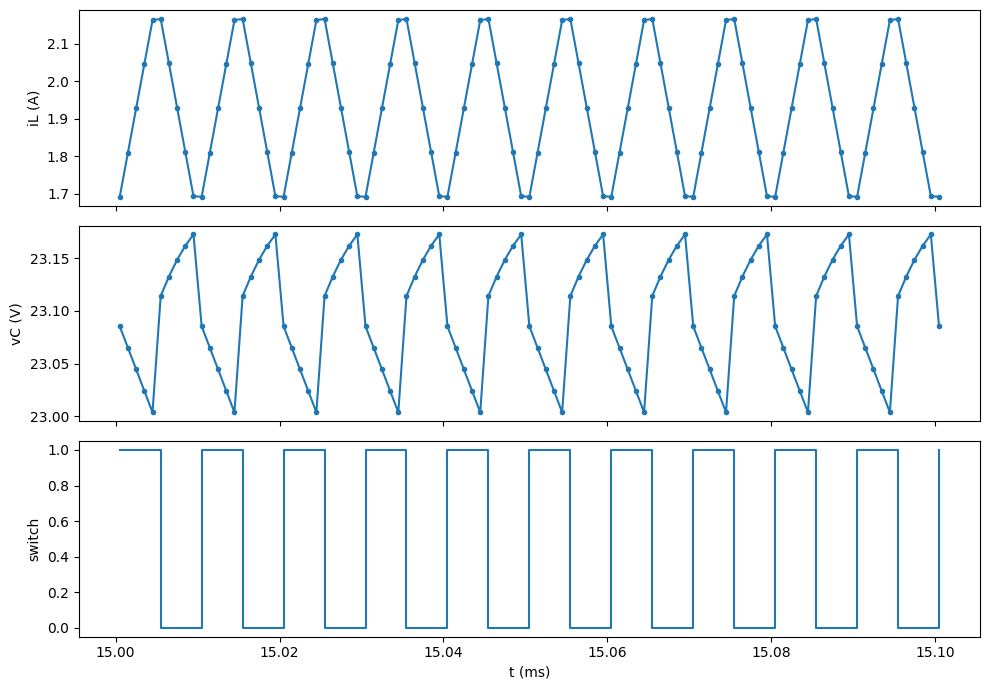

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv("boost_clean.csv")
zoom = df[df.t < df.t.iloc[0] + 100e-6]    # ~10 switching cycles

fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
ax[0].plot(zoom.t*1e3, zoom.iL, ".-");  ax[0].set_ylabel("iL (A)")
ax[1].plot(zoom.t*1e3, zoom.vC, ".-");  ax[1].set_ylabel("vC (V)")
ax[2].step(zoom.t*1e3, zoom.switch_state, where="post"); ax[2].set_ylabel("switch")
ax[2].set_xlabel("t (ms)")
plt.tight_layout(); plt.show()

In [ ]:
files.download("boost_clean.csv")   # saves it to your PC

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>